In [ ]:
import pandas as pd

# Carregando as principais tabelas (ajuste o caminho se necessário)
clientes = pd.read_csv('olist_customers_dataset.csv')
pedidos = pd.read_csv('olist_orders_dataset.csv')
itens = pd.read_csv('olist_order_items_dataset.csv')
pagamentos = pd.read_csv('olist_order_payments_dataset.csv')

# Visualizando as primeiras linhas dos pedidos para entender as colunas e datas
print("--- PEDIDOS ---")
display(pedidos.head())

print("\n--- ITENS DOS PEDIDOS ---")
display(itens.head())

--- PEDIDOS ---


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00



--- ITENS DOS PEDIDOS ---


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [ ]:
import pandas as pd

# 1. Carregando as tabelas (certifique-se de que os arquivos estão na mesma pasta do seu Colab/Notebook)
pedidos = pd.read_csv('olist_orders_dataset.csv')
itens = pd.read_csv('olist_order_items_dataset.csv')

# 2. Fazendo o MERGE (Cruzamento) das tabelas usando 'order_id'
# Usamos o 'inner' para garantir que só vamos analisar pedidos que realmente aconteceram e têm itens.
df_completo = pd.merge(itens, pedidos, on='order_id', how='inner')

# 3. Tratando as datas: convertendo a coluna de data de compra para o formato de Data do Pandas
df_completo['order_purchase_timestamp'] = pd.to_datetime(df_completo['order_purchase_timestamp'])

# 4. Criando uma coluna apenas com o Ano-Mês (ex: 2017-08) para facilitar o agrupamento temporal
df_completo['ano_mes'] = df_completo['order_purchase_timestamp'].dt.to_period('M')

# 5. Calculando o faturamento total por mês
# O faturamento de um item é o preço (price) somado ao valor do frete (freight_value), ou apenas o preço do produto.
# Vamos usar o 'price' para o faturamento bruto de vendas:
faturamento_mensal = df_completo.groupby('ano_mes')['price'].sum().reset_index()

# Renomeando as colunas para ficar elegante
faturamento_mensal.columns = ['Mes', 'Faturamento_Total']

# 6. Exibindo o resultado formatado
print("--- FATURAMENTO MENSAL DA OLIST ---")
display(faturamento_mensal)

--- FATURAMENTO MENSAL DA OLIST ---


,Mes,Faturamento_Total
0,2016-09,267.36
1,2016-10,49507.66
2,2016-12,10.90
3,2017-01,120312.87
4,2017-02,247303.02
5,2017-03,374344.30
6,2017-04,359927.23
7,2017-05,506071.14
8,2017-06,433038.60
9,2017-07,498031.48


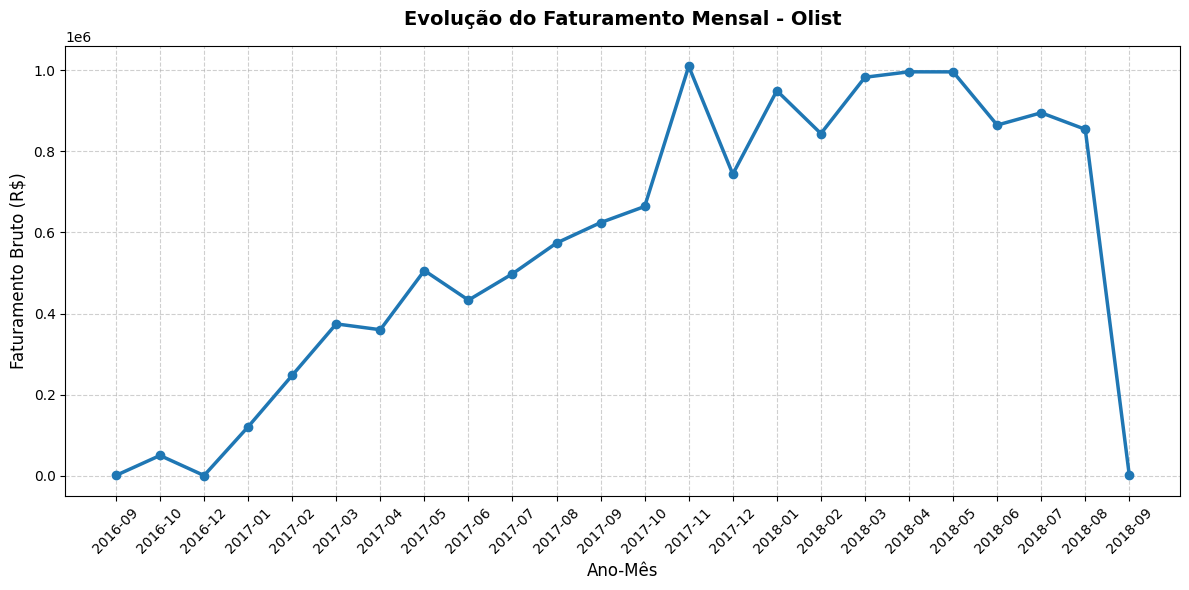

In [ ]:
import matplotlib.pyplot as plt

# 1. Convertendo a coluna 'Mes' de volta para string para o gráfico não se perder nas datas
faturamento_mensal['Mes_str'] = faturamento_mensal['Mes'].astype(str)

# 2. Configurando o tamanho da figura
plt.figure(figsize=(12, 6))

# 3. Criando o gráfico de linhas
plt.plot(faturamento_mensal['Mes_str'],
         faturamento_mensal['Faturamento_Total'],
         marker='o',          # Adiciona bolinhas em cada ponto de mês
         linestyle='-',       # Linha contínua
         linewidth=2.5,       # Espessura da linha
         color='#1f77b4')     # Cor azul profissional

# 4. Adicionando títulos e rótulos (Essencial para um bom portfólio!)
plt.title('Evolução do Faturamento Mensal - Olist', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Ano-Mês', fontsize=12)
plt.ylabel('Faturamento Bruto (R$)', fontsize=12)

# 5. Rotacionando os meses no eixo X para não embolarem e adicionando grade de fundo
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)

# 6. Exibindo o gráfico limpo
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

# 1. Carregando as novas tabelas necessárias
produtos = pd.read_csv('olist_products_dataset.csv')
traducao = pd.read_csv('product_category_name_translation.csv')

# 2. Fazendo a tradução dos nomes das categorias para o português
# (A tabela de produtos original vem com os nomes em inglês, ex: 'health_beauty')
produtos_traduzidos = pd.merge(produtos, traducao, on='product_category_name', how='left')

# 3. Agora fazemos o merge da nossa base de itens anterior com a tabela de produtos
# Vamos usar o 'product_id' como chave de ligação entre 'df_completo' (dos passos anteriores) e 'produtos_traduzidos'
df_com_categorias = pd.merge(df_completo, produtos_traduzidos[['product_id', 'product_category_name_english']], on='product_id', how='left')

# (Opcional) Se preferir deixar o nome em português limpo, podemos criar uma coluna amigável:
df_com_categorias['categoria'] = df_com_categorias['product_category_name_english'].fillna('outros')

# 4. Agrupando por categoria e somando o faturamento (price)
top_categorias = df_com_categorias.groupby('categoria')['price'].sum().reset_index()

# 5. Ordenando do maior para o menor faturamento e pegando apenas os Top 5
top_5_categorias = top_categorias.sort_values(by='price', ascending=False).head(5)

# Renomeando as colunas para exibição
top_5_categorias.columns = ['Categoria', 'Faturamento_Total']

print("--- TOP 5 CATEGORIAS QUE MAIS GERAM RECEITA ---")
display(top_5_categorias)

--- TOP 5 CATEGORIAS QUE MAIS GERAM RECEITA ---


,Categoria,Faturamento_Total
43,health_beauty,1258681.34
71,watches_gifts,1205005.68
7,bed_bath_table,1036988.68
66,sports_leisure,988048.97
15,computers_accessories,911954.32


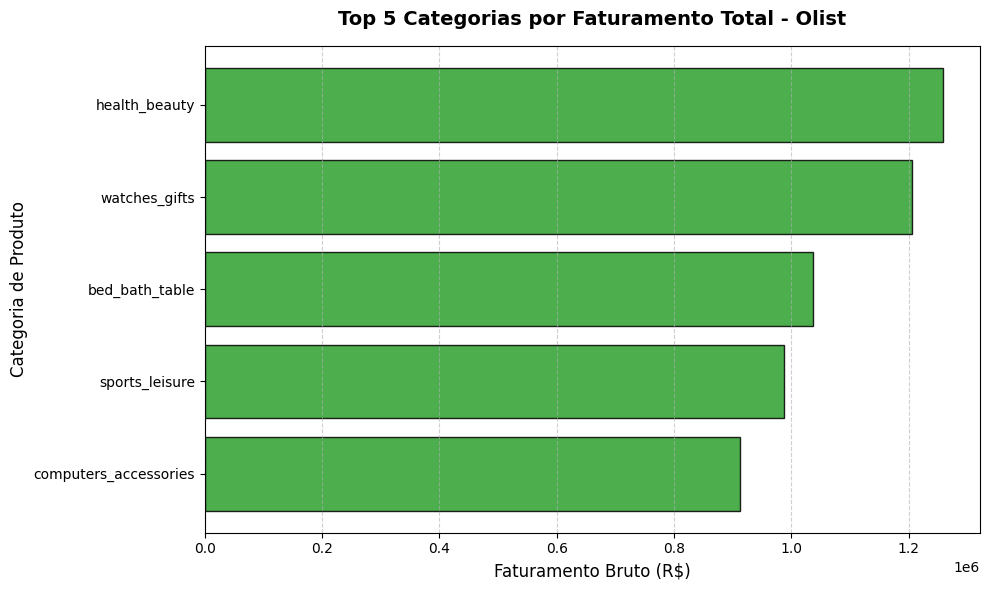

In [ ]:
import matplotlib.pyplot as plt

# 1. Ordenando do menor para o maior para que o maior fique no TOPO do gráfico horizontal
top_5_ordenado = top_5_categorias.sort_values(by='Faturamento_Total', ascending=True)

# 2. Configurando o tamanho da figura
plt.figure(figsize=(10, 6))

# 3. Criando o gráfico de barras horizontais (.barh)
plt.barh(top_5_ordenado['Categoria'],
         top_5_ordenado['Faturamento_Total'],
         color='#2ca02c',     # Verde corporativo
         edgecolor='black',   # Borda sutil nas barras
         alpha=0.85)

# 4. Adicionando títulos e rótulos
plt.title('Top 5 Categorias por Faturamento Total - Olist', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Faturamento Bruto (R$)', fontsize=12)
plt.ylabel('Categoria de Produto', fontsize=12)

# 5. Adicionando uma grade de fundo apenas no eixo X para facilitar a leitura dos valores
plt.grid(axis='x', linestyle='--', alpha=0.6)

# 6. Exibindo o gráfico ajustado
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

# 1. Carregando a tabela de avaliações (reviews)
avaliacoes = pd.read_csv('olist_order_reviews_dataset.csv')

# 2. Garantindo que o 'df_completo' (criado nos passos anteriores) tem as colunas de datas de entrega
# As colunas importantes na tabela de pedidos são:
# 'order_delivered_customer_date' (data real) e 'order_estimated_delivery_date' (data estimada)
# Como o 'df_completo' já veio da tabela de pedidos, vamos usar as colunas dele.

# 3. Convertendo as colunas de data de entrega para o formato datetime
df_completo['order_delivered_customer_date'] = pd.to_datetime(df_completo['order_delivered_customer_date'])
df_completo['order_estimated_delivery_date'] = pd.to_datetime(df_completo['order_estimated_delivery_date'])

# 4. Calculando os dias de atraso (Data Real - Data Estimada)
# Se o resultado for maior que 0, o pedido atrasou. Se for menor ou igual a 0, chegou no prazo ou adiantado.
df_completo['dias_atraso'] = (df_completo['order_delivered_customer_date'] - df_completo['order_estimated_delivery_date']).dt.days

# 5. Fazendo o merge com a tabela de avaliações usando o 'order_id'
# (Como um pedido pode ter múltiplos itens, vamos remover duplicadas de order_id para a avaliação não duplicar)
avaliacoes_unicas = avaliacoes.drop_duplicates(subset=['order_id'])
df_com_feedback = pd.merge(df_completo, avaliacoes_unicas[['order_id', 'review_score']], on='order_id', how='inner')

# 6. Criando uma coluna categórica simples: Atrasou ou não atrasou?
df_completo_status_atraso = df_com_feedback.dropna(subset=['order_delivered_customer_date', 'review_score']).copy()
df_com_feedback['status_entrega'] = df_com_feedback['dias_atraso'].apply(lambda x: 'Atrasado' if x > 0 else 'No Prazo / Adiantado')

# 7. Calculando a Nota Média (review_score) de acordo com o status da entrega
impacto_atraso = df_com_feedback.groupby('status_entrega')['review_score'].mean().reset_index()
impacto_atraso.columns = ['Status_Entrega', 'Nota_Media']

print("--- IMPACTO DA ENTREGA NA SATISFAÇÃO DO CLIENTE ---")
display(impacto_atraso)

--- IMPACTO DA ENTREGA NA SATISFAÇÃO DO CLIENTE ---


,Status_Entrega,Nota_Media
0,Atrasado,2.257199
1,No Prazo / Adiantado,4.153789


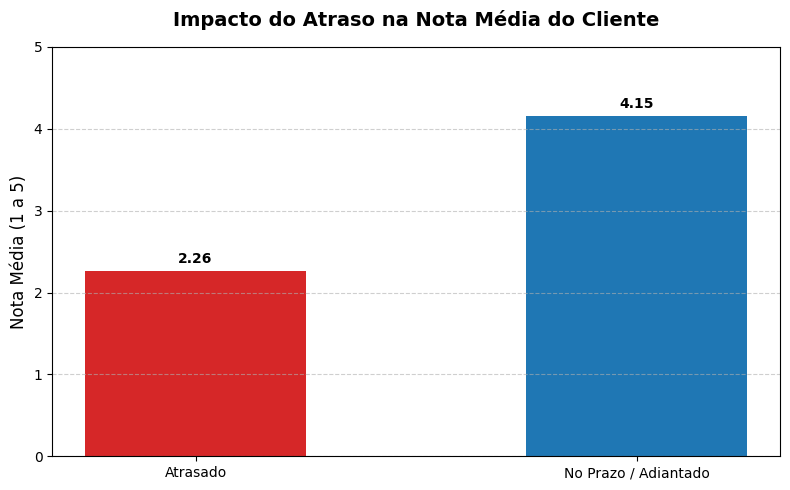

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.bar(impacto_atraso['Status_Entrega'],
        impacto_atraso['Nota_Media'],
        color=['#d62728', '#1f77b4'], # Vermelho para atrasado, Azul para no prazo
        width=0.5)

plt.title('Impacto do Atraso na Nota Média do Cliente', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Nota Média (1 a 5)', fontsize=12)
plt.ylim(0, 5) # O limite da nota é 5
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Adicionando os valores em cima de cada barra
for i, v in enumerate(impacto_atraso['Nota_Media']):
    plt.text(i, v + 0.1, f"{v:.2f}", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()